<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="300" alt="Skills Network Logo">
    </a>
</p>


# **Hands-on practice lab: Model Development**

Estimated time needed: **45** minutes

In this lab, you will use the skills acquired in throughout the module, and use linear regression principles to create a model that predicts the Price of the laptop, based on one or more attributes of the dataset.


# Objectives

After completing this lab you will be able to:

 - Use Linear Regression in one variable to fit the parameters to a model
 - Use Linear Regression in multiple variables to fit the parameters to a model
 - Use Polynomial Regression in single variable tofit the parameters to a model
 - Create a pipeline for performing linear regression using multiple features in polynomial scaling
 - Evaluate the performance of different forms of regression on basis of MSE and R^2 parameters


# Setup


For this lab, we will be using the following libraries:

*   [`pandas`](https://pandas.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for managing the data.
*   [`numpy`](https://numpy.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for mathematical operations.
*   [`sklearn`](https://scikit-learn.org/stable/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for machine learning and machine-learning-pipeline related functions.
*   [`seaborn`](https://seaborn.pydata.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for visualizing the data.
*   [`matplotlib`](https://matplotlib.org/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML0187ENSkillsNetwork31430127-2021-01-01) for additional plotting tools.


### Importing Required Libraries

_We recommend you import all required libraries in one place (here):_


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore", category=UserWarning) 
%matplotlib inline

### Importing the dataset
Run the cell below to download the dataset into this environment.

This function will download the dataset into your browser


In [2]:
df = pd.read_csv("laptops.csv", header=0).iloc[:, 2:]

In [3]:
# show the first 5 rows using dataframe.head() method
print("The first 5 rows of the dataframe") 
df.head(5)

The first 5 rows of the dataframe


,Manufacturer,Category,GPU,OS,CPU_core,Screen_Size_inch,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_pounds,Price,Price-binned,Screen-Full_HD,Screen-IPS_panel
0,Acer,4,2,1,5,14.0,0.551724,8,256,3.52800,978,Low,0,1
1,Dell,3,1,1,3,15.6,0.689655,4,256,4.85100,634,Low,1,0
2,Dell,3,1,1,7,15.6,0.931034,8,256,4.85100,946,Low,1,0
3,Dell,4,2,1,5,13.3,0.551724,8,128,2.69010,1244,Low,0,1
4,HP,4,2,1,7,15.6,0.620690,8,256,4.21155,837,Low,1,0


# Task 1 : Single Linear Regression

You have learnt that "CPU_frequency" is the parameter with the lowest p-value among the different features of the dataset. Create a single feature Linear Regression model that fits the pair of "CPU_frequency" and "Price" to find the model for prediction.


In [4]:
# Write your code below and press Shift+Enter to execute 
model = LinearRegression()
x = df[["CPU_frequency"]]
y = df["Price"]
model.fit(x, y)
y_pred = model.predict(x)

Generate the Distribution plot for the predicted values and that of the actual values. How well did the model perform?


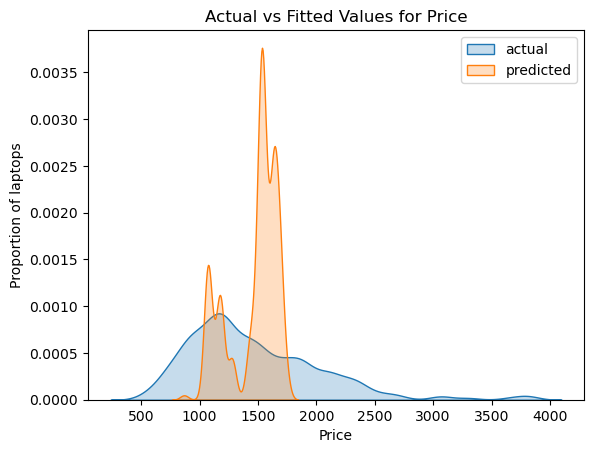

In [5]:
# Write your code below and press Shift+Enter to execute 
sns.kdeplot(x=y, multiple="layer", bw_adjust=0.5, fill=True, label="actual")
sns.kdeplot(x=y_pred, multiple="layer", bw_adjust=0.5, fill=True, label="predicted")
plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.legend()

Evaluate the Mean Squared Error and R^2 score values for the model. 


In [6]:
# Write your code below and press Shift+Enter to execute 
r2 = r2_score(y, y_pred)
mse=mean_squared_error(y, y_pred)
print(f"r2 score is {r2}", "\n" ,f"mean squared error is {mse}")

r2 score is 0.1344436321024326 
 mean squared error is 284583.4405868629


# Task 2 - Multiple Linear Regression
The parameters which have a low enough p-value so as to indicate strong relationship with the 'Price' value are 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU' and 'Category'. Use all these variables to create a Multiple Linear Regression system. 


In [7]:
# Write your code below and press Shift+Enter to execute 
x_group = df[['CPU_frequency', 'RAM_GB', 'Storage_GB_SSD', 'CPU_core', 'OS', 'GPU', 'Category']]
model2 = LinearRegression()
model2.fit(x_group, y)
y_pred_2 = model2.predict(x_group)

Plot the Distribution graph of the predicted values as well as the Actual values


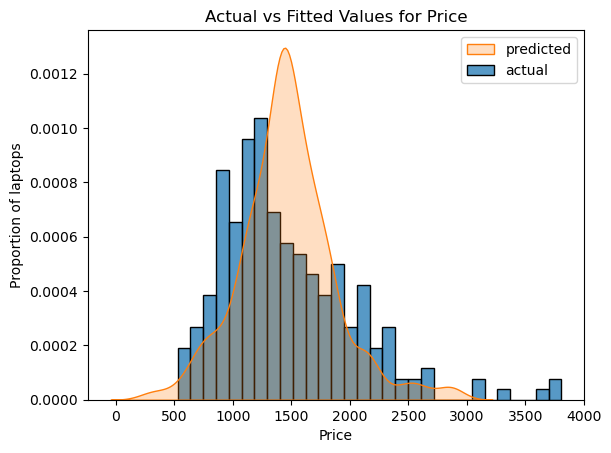

In [8]:
# Write your code below and press Shift+Enter to execute
sns.histplot(x=y, bins=30, multiple="layer", stat="density", label="actual")
sns.kdeplot(x=y_pred_2, multiple="layer", bw_adjust=0.8, fill=True, label="predicted")
plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.legend()

Find the R^2 score and the MSE value for this fit. Is this better or worst than the performance of Single Linear Regression?


In [11]:
# Write your code below and press Shift+Enter to execute
r2 = r2_score(y, y_pred_2)
mse=mean_squared_error(y, y_pred_2)
print(f"r2 score is {r2}", "\n" ,f"mean squared error is {mse}")

r2 score is 0.5082509055187376 
 mean squared error is 161680.57263893104


# Task 3 - Polynomial Regression
Use the variable "CPU_frequency" to create Polynomial features. Try this for 3 different values of polynomial degrees. Remember that polynomial fits are done using `numpy.polyfit`. 


In [12]:
#  Write your code below and press Shift+Enter to execute
def polly(degree):
    pol = PolynomialFeatures(degree = degree, include_bias=False)
    X = pol.fit_transform(x)
    model = LinearRegression()
    model.fit(X, y)
    return model.predict(X) 

y_pred_1 = polly(1)
y_pred_3 = polly(3)
y_pred_5 = polly(5)

Plot the regression output against the actual data points to note how the data fits in each case. Also, calculate the R^2 and MSE values for these fits. 


r2 score is 0.1344436321024326 
 mean squared error is 284583.4405868629


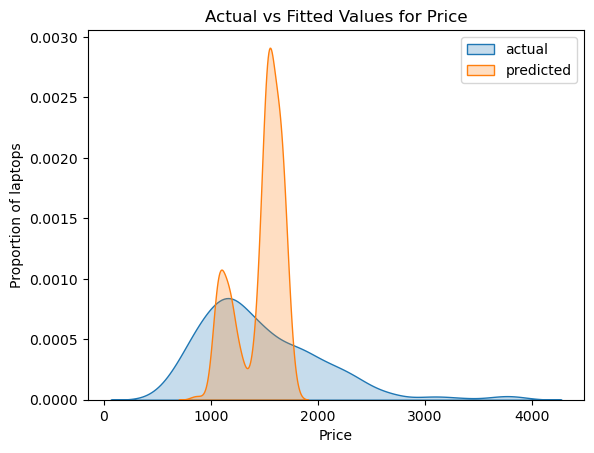

In [13]:
#  Write your code below and press Shift+Enter to execute
# Call for function of degree 1
r2 = r2_score(y, y_pred_1)
mse=mean_squared_error(y, y_pred_1)
print(f"r2 score is {r2}", "\n" ,f"mean squared error is {mse}")


sns.kdeplot(x=y, multiple="layer", bw_adjust=0.8, fill=True, label="actual")
sns.kdeplot(x=y_pred_1, multiple="layer", bw_adjust=0.8, fill=True, label="predicted")
plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.legend()

r2 score is 0.2669264079653113 
 mean squared error is 241024.86303848765


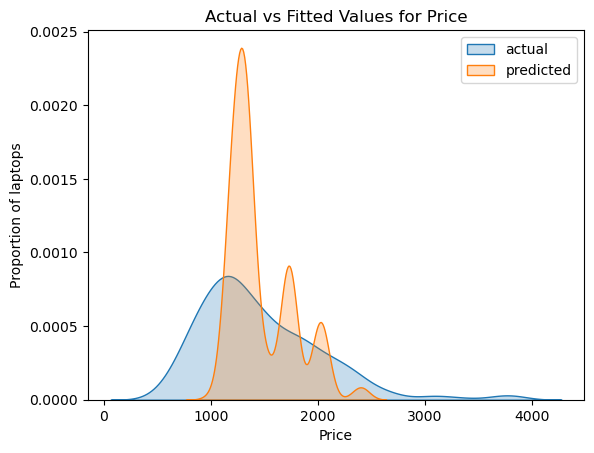

In [14]:
#  Write your code below and press Shift+Enter to execute
# Call for function of degree 3
r2 = r2_score(y, y_pred_3)
mse=mean_squared_error(y, y_pred_3)
print(f"r2 score is {r2}", "\n" ,f"mean squared error is {mse}")

sns.kdeplot(x=y, multiple="layer", bw_adjust=0.8, fill=True, label="actual")
sns.kdeplot(x=y_pred_3, multiple="layer", bw_adjust=0.8, fill=True, label="predicted")
plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.legend()

r2 score is 0.30308227064434 
 mean squared error is 229137.29548055152


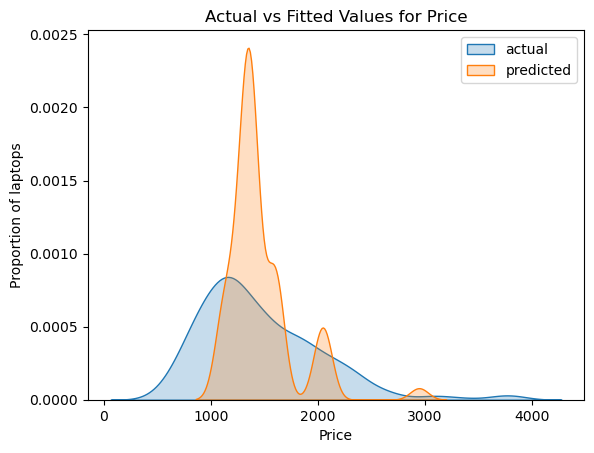

In [15]:
#  Write your code below and press Shift+Enter to execute
# Call for function of degree 5
r2 = r2_score(y, y_pred_5)
mse=mean_squared_error(y, y_pred_5)
print(f"r2 score is {r2}", "\n" ,f"mean squared error is {mse}")


sns.kdeplot(x=y, multiple="layer", bw_adjust=0.8, fill=True, label="actual")
sns.kdeplot(x=y_pred_5, multiple="layer", bw_adjust=0.8, fill=True, label="predicted")
plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.legend()

# Task 4 - Pipeline
Create a pipeline that performs parameter scaling, Polynomial Feature generation and Linear regression. Use the set of multiple features as before to create this pipeline. 


In [16]:
#  Write your code below and press Shift+Enter to execute
input=[
    ("pol", PolynomialFeatures(degree=5, include_bias=False)),
     ("model", LinearRegression())
]
pipe=Pipeline(input)
pipe.fit(x_group, y)
y_pred_pipe = pipe.predict(x_group)

Evaluate the MSE and R^2 values for the this predicted output.


r2 score is 0.7690566794662437 
 mean squared error is 75931.09724060039


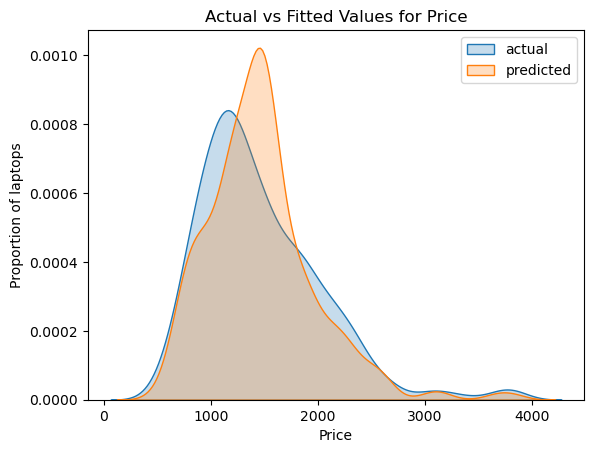

In [17]:
#  Write your code below and press Shift+Enter to execute
r2 = r2_score(y, y_pred_pipe)
mse=mean_squared_error(y, y_pred_pipe)
print(f"r2 score is {r2}", "\n" ,f"mean squared error is {mse}")

sns.kdeplot(x=y, multiple="layer", bw_adjust=0.8, fill=True, label="actual")
sns.kdeplot(x=y_pred_pipe, multiple="layer", bw_adjust=0.8, fill=True, label="predicted")
plt.title('Actual vs Fitted Values for Price')
plt.xlabel('Price')
plt.ylabel('Proportion of laptops')
plt.legend()

You should now have seen that the values of R^2 increase as we go from Single Linear Regression to Multiple Linear Regression. Further, if we go for multiple linear regression extended with polynomial features, we get an even better R^2 value.


# Congratulations! You have completed the lab


## Authors


[Abhishek Gagneja](https://www.coursera.org/instructor/~129186572)

[Vicky Kuo](https://author.skills.network/instructors/vicky_kuo)


### Copyright ©IBM Corporation. All rights reserved.
